I am working with my reserach data. The dataset are timeseries dataset. In this project I am trying to predict planting dates.There are 10 features which are: <br>
meana: the minimum EVI value before the growing season <br>
meanb: the minimum EVI value after the growing season <br>
maxevi: the maximum EVI value during the growing season <br>
meang1: The difference between the maxevi and meana <br>
meang2: The difference between the maxevi and meanb <br>
meandoy: the day of the year where the max evi has been reached <br>
meanTemp: The mean temperature of the growing season <br>
meanDSWR: the mean temperature of the growing season <br>
meanTmax: the mean of the maximum temperature of the growing season <br>

We will try to predict meanDOP. We will use three algorithms Random forest, Gradient boosting, and Neural network. We split the dataset into 0.75 and 0.25 ratio and run them for 100 iterations.


In [22]:
# Mount Google drive and read the data

In [23]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

# Define the file path
file_path = '/content/drive/MyDrive/DOPDOHdata/128sites/EVIallRicefieldssummarised.csv'

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first few rows of the dataframe
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   doyb  doya            type  count  meana  meanb  maxevi  meang1  meang2  \
0   296    40    2015_Baker20     37  0.027  0.112   0.572   0.545   0.460   
1   296    40    2015_Baker30     37  0.027  0.112   0.572   0.545   0.460   
2   296    40    2015_Baker40     37  0.038  0.097   0.585   0.547   0.488   
3   296    48    2015_Baker50     37 -0.010  0.102   0.654   0.664   0.552   
4   296    48  2015_BottOfRes     37 -0.021  0.118   0.607   0.628   0.489   

   meanDOP  meanDOH  meandoy    meanDSWR    meanTemp  meanLSWi    meanTmax  \
0      112      244      200  214.352243  291.983649  0.224216  294.582865   
1      112      243      200  214.352243  291.983649  0.224216  294.582865   
2      112      244      200  214.352243  291.983649  0.223324  294.582865   
3      112      244      200  214.352243  291.983649  0.243703  294.582865   
4      113  

In [24]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the features and target variables
features = ['meana', 'meanb', 'maxevi', 'meang1', 'meang2', 'meandoy', 'meanDSWR', 'meanTemp', 'meanLSWi', 'meanTmax']
target = 'meanDOP'

# Define the dataframe with features and target
X = df[features]
y = df[target]

# Define k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store MSE for each fold
mse_train_list = []
mse_test_list = []

# Perform 100 iterations of k-fold cross-validation
for _ in range(100):
    # Perform k-fold cross-validation
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Further split the training set into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

        # Create a Random Forest regressor
        model = RandomForestRegressor()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions on the training set
        train_predictions = model.predict(X_train)

        # Make predictions on the validation set
        val_predictions = model.predict(X_val)

        # Calculate MSE for training and validation sets
        mse_train = mean_squared_error(y_train, train_predictions)
        mse_val = mean_squared_error(y_val, val_predictions)

        # Append MSE to lists
        mse_train_list.append(mse_train)
        mse_test_list.append(mse_val)

# Calculate average MSE for training and testing sets
avg_mse_train = sum(mse_train_list) / len(mse_train_list)
avg_mse_test = sum(mse_test_list) / len(mse_test_list)

print("Average MSE for training set over 100 iterations:", avg_mse_train)
print("Average MSE for validation set over 100 iterations:", avg_mse_test)


Average MSE for training set over 100 iterations: 15.13243972057009
Average MSE for validation set over 100 iterations: 81.95823294601973


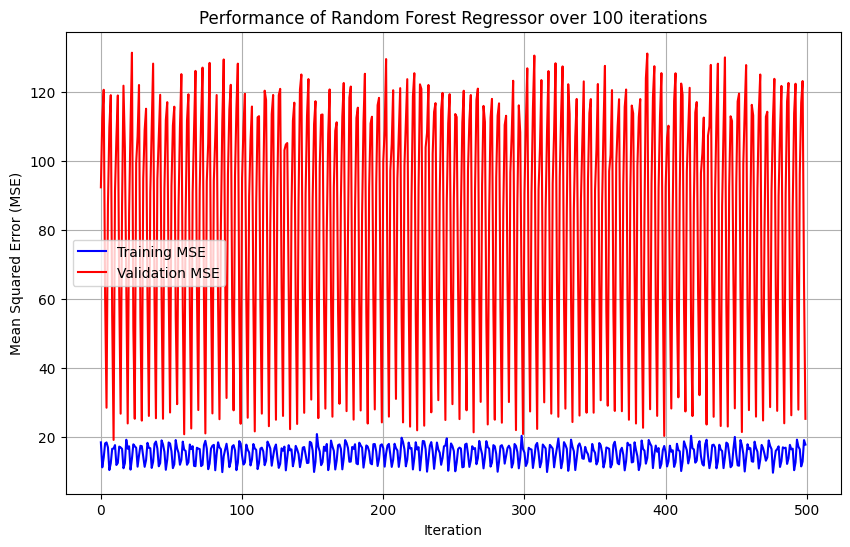

In [25]:
import matplotlib.pyplot as plt

# Plot MSE values
plt.figure(figsize=(10, 6))
plt.plot(range(len(mse_train_list)), mse_train_list, label='Training MSE', color='blue')
plt.plot(range(len(mse_test_list)), mse_test_list, label='Validation MSE', color='red')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Performance of Random Forest Regressor over 100 iterations')
plt.legend()
plt.grid(True)
Randomforesturun = "random_forest_mse_plot.png"
# Define the file path
file_path = '/content/drive/MyDrive/DOPDOHdata/128sites'
plt.savefig(file_path + '/' + Randomforesturun)

plt.show()


In [26]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the features and target variables
features = ['meana', 'meanb', 'maxevi', 'meang1', 'meang2',  'meandoy', 'meanDSWR', 'meanTemp', 'meanLSWi']
target = 'meanDOP'

# Define the dataframe with features and target
X = df[features]
y = df[target]

# Define k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store MSE for each fold
mse_train_list = []
mse_test_list = []
feature_importance_list = []

# Perform k-fold cross-validation
for train_index, test_index in kf.split(X):
    # Split the data into training and testing sets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Further split the training set into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

    # Create a Random Forest regressor
    model = RandomForestRegressor()

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the training set
    train_predictions = model.predict(X_train)

    # Make predictions on the validation set
    val_predictions = model.predict(X_val)

    # Calculate MSE for training and validation sets
    mse_train = mean_squared_error(y_train, train_predictions)
    mse_val = mean_squared_error(y_val, val_predictions)

    # Append MSE to lists
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_val)

    # Get feature importances
    feature_importance_list.append(model.feature_importances_)

# Calculate average MSE for training and testing sets
avg_mse_train = sum(mse_train_list) / len(mse_train_list)
avg_mse_test = sum(mse_test_list) / len(mse_test_list)

print("Average MSE for training set:", avg_mse_train)
print("Average MSE for validation set:", avg_mse_test)

# Calculate average feature importance
avg_feature_importance = np.mean(feature_importance_list, axis=0)
sorted_indices = np.argsort(avg_feature_importance)[::-1]  # Sort indices in descending order

# Print feature ranking
print("\nFeature Ranking:")
for i, idx in enumerate(sorted_indices):
    print(f"{i+1}. {features[idx]}: {avg_feature_importance[idx]}")


Average MSE for training set: 14.466885010234495
Average MSE for validation set: 79.16521959983973

Feature Ranking:
1. maxevi: 0.1981230231653213
2. meanb: 0.16602429798870497
3. meanTemp: 0.13020511009439514
4. meandoy: 0.11773475151536712
5. meanLSWi: 0.09866607784243238
6. meanDSWR: 0.08424983930789678
7. meang2: 0.08107567346618391
8. meang1: 0.06640871288654217
9. meana: 0.05751251373315628


In [27]:
from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the features and target variables
features = ['meana', 'meanb', 'maxevi', 'meang1', 'meang2', 'meandoy', 'meanDSWR', 'meanTemp', 'meanLSWi', 'meanTmax']
target = 'meanDOP'

# Define the dataframe with features and target
X = df[features]
y = df[target]

# Define k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store MSE for each fold
mse_train_list = []
mse_test_list = []

# Perform 100 iterations of k-fold cross-validation
for _ in range(100):
    # Perform k-fold cross-validation
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Further split the training set into training and validation sets
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

        # Create a Gradient Boosting regressor
        model = GradientBoostingRegressor()

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions on the training set
        train_predictions = model.predict(X_train)

        # Make predictions on the validation set
        val_predictions = model.predict(X_val)

        # Calculate MSE for training and validation sets
        mse_train = mean_squared_error(y_train, train_predictions)
        mse_val = mean_squared_error(y_val, val_predictions)

        # Append MSE to lists
        mse_train_list.append(mse_train)
        mse_test_list.append(mse_val)

# Calculate average MSE for training and testing sets
avg_mse_train = sum(mse_train_list) / len(mse_train_list)
avg_mse_test = sum(mse_test_list) / len(mse_test_list)

print("Average MSE for training set over 100 iterations:", avg_mse_train)
print("Average MSE for validation set over 100 iterations:", avg_mse_test)


Average MSE for training set over 100 iterations: 4.30193298803449
Average MSE for validation set over 100 iterations: 94.97315802941473


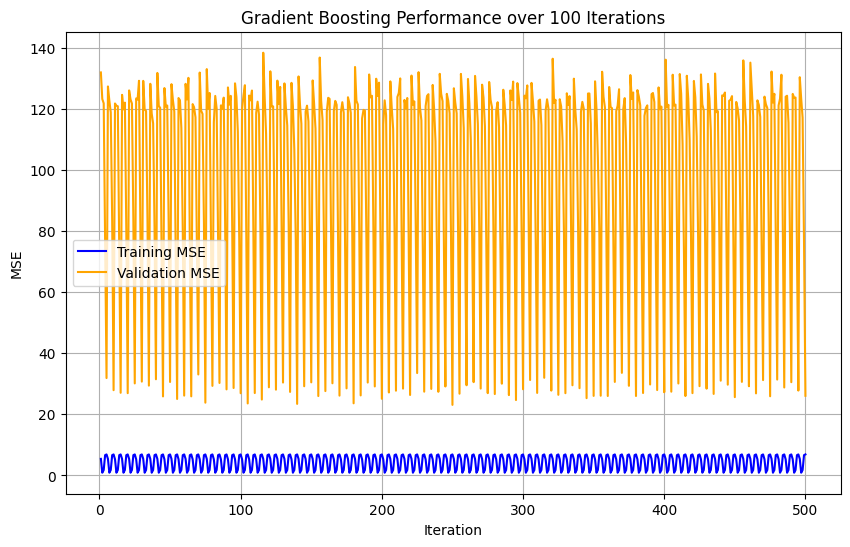

In [28]:
import matplotlib.pyplot as plt

# Plot MSE for training and validation sets
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mse_train_list) + 1), mse_train_list, label='Training MSE', color='blue')
plt.plot(range(1, len(mse_test_list) + 1), mse_test_list, label='Validation MSE', color='orange')
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Boosting Performance over 100 Iterations')
plt.legend()
plt.grid(True)

gradeintboost_mse_plot = "gradeintboost_mse_plot.png"
# Define the file path
file_path = '/content/drive/MyDrive/DOPDOHdata/128sites'
plt.savefig(file_path + '/' + gradeintboost_mse_plot)
plt.show()


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

# Evaluate the model
mse_test = model.evaluate(X_test, y_test, verbose=0)
print("Mean squared error on test set:", mse_test)


Mean squared error on test set: 498.1556091308594


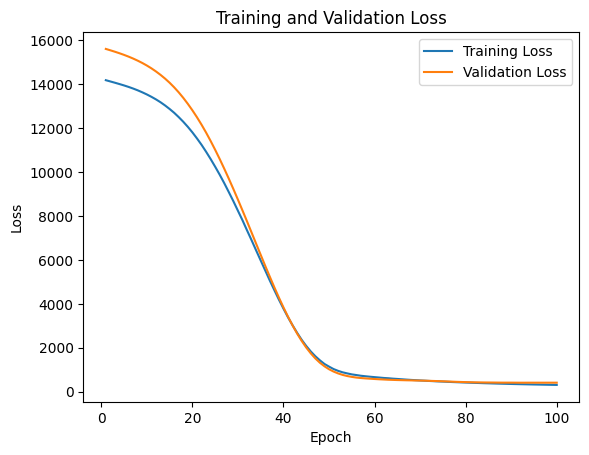

In [30]:
import matplotlib.pyplot as plt

# Extract training and validation loss from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation loss
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
ANNMSEplot = "ANNMSEplot.png"
# Define the file path
file_path = '/content/drive/MyDrive/DOPDOHdata/128sites'
plt.savefig(file_path + '/' + ANNMSEplot)
plt.show()


In [31]:
### Random forest performs better than all other algorithms
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest regressor
rf_model = RandomForestRegressor()

# Train the model on the entire dataset
rf_model.fit(X, y)

# Predict the target variable for the entire dataset
predictions = rf_model.predict(X)

# Print the predictions
print(predictions)


[111.865      111.865      111.0725     104.4325     112.1125
 122.95533333 123.14       122.56166667 136.61        95.64802381
 126.0125      97.1007619   97.1007619  123.52733333 120.6
 147.2375     147.05       122.52       118.285      123.125
 126.452      101.64666667 109.02       140.17666667  97.97971429
  97.97971429 122.95533333 125.17       125.6        122.55166667
 125.51       125.27       123.235       97.571      113.09
  94.75966667  95.64802381 114.7        100.26166667 101.89566667
 104.4325      96.823      134.03        96.35009524 114.63
 113.70666667 114.76       114.76       115.65       136.48
 122.64       124.35       135.5        122.95       128.91
 109.81       137.04       111.87       112.11       111.91583333
 118.33       116.31       132.27333333 146.91       118.04
 117.88       117.88       120.21       127.91716667 132.20666667
 127.91716667 109.77       109.77       133.66833333 141.5
 121.775      118.93       135.69       122.78       117.439166

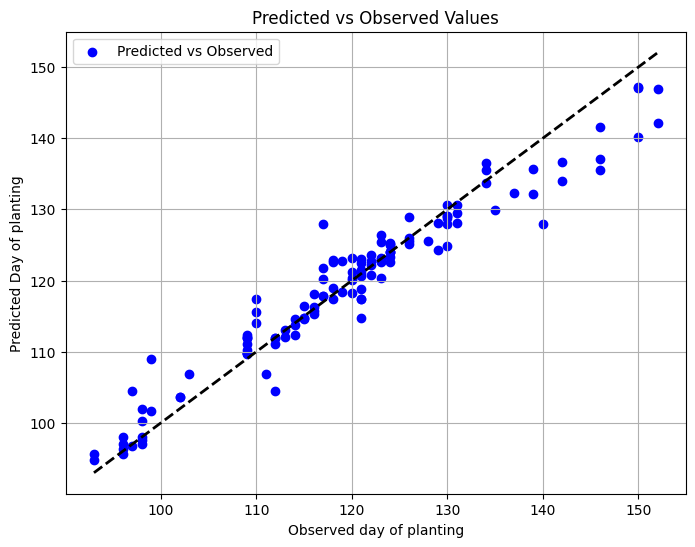

In [32]:
import matplotlib.pyplot as plt

# Plot predicted vs observed values
plt.figure(figsize=(8, 6))
plt.scatter(y, predictions, color='blue', label='Predicted vs Observed')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--k', lw=2)
plt.xlabel('Observed day of planting')
plt.ylabel('Predicted Day of planting')
plt.title('Predicted vs Observed Values')
plt.legend(loc='upper left')
plt.grid(True)

PreOBsranfore = "PreOBsranfore.png"
# Define the file path
file_path = '/content/drive/MyDrive/DOPDOHdata/128sites'
plt.savefig(file_path + '/' + PreOBsranfore)
plt.show()
